In [232]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
import statsmodels.formula.api as smf


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rutuspatel/walmart-dataset-retail/Walmart_Store_sales.csv


In [233]:
file_path = '/kaggle/input/datasets/rutuspatel/walmart-dataset-retail/Walmart_Store_sales.csv'

df = pd.read_csv(file_path)
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [234]:
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [235]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [237]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [238]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [239]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)



In [240]:
df.dtypes


Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

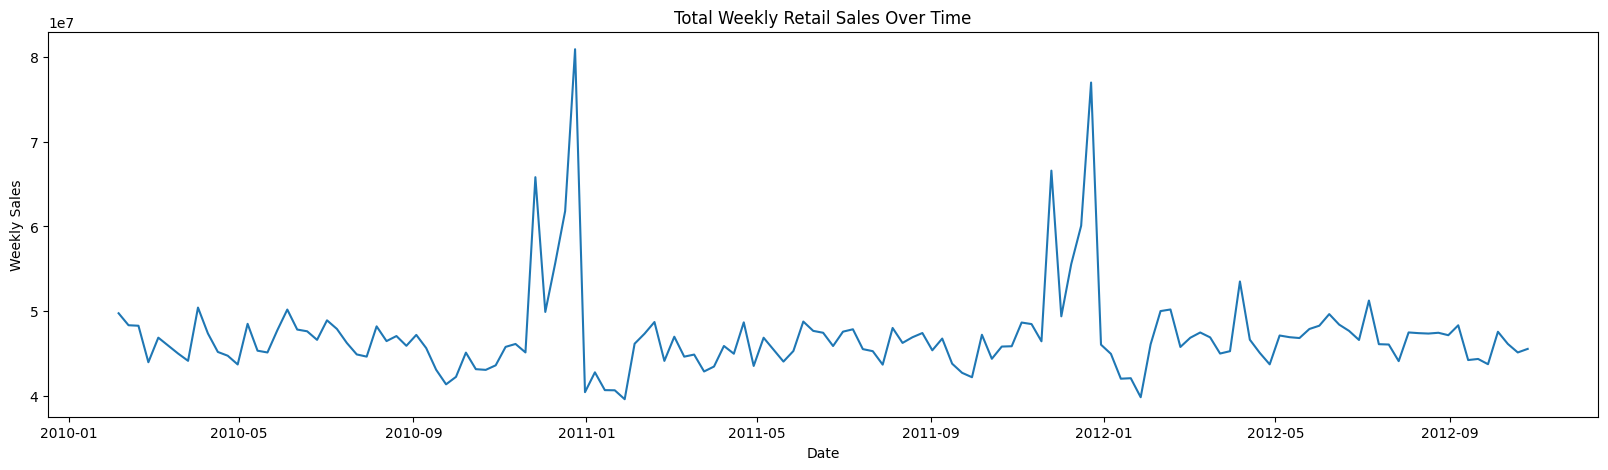

In [241]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(20,5))
plt.plot(weekly_total)
plt.title('Total Weekly Retail Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()


In [242]:
df['Store'] = df['Store'].astype('category')

In [243]:
df.duplicated(subset=['Store', 'Date']).sum()


np.int64(0)

In [244]:
df['Store'].nunique()


45

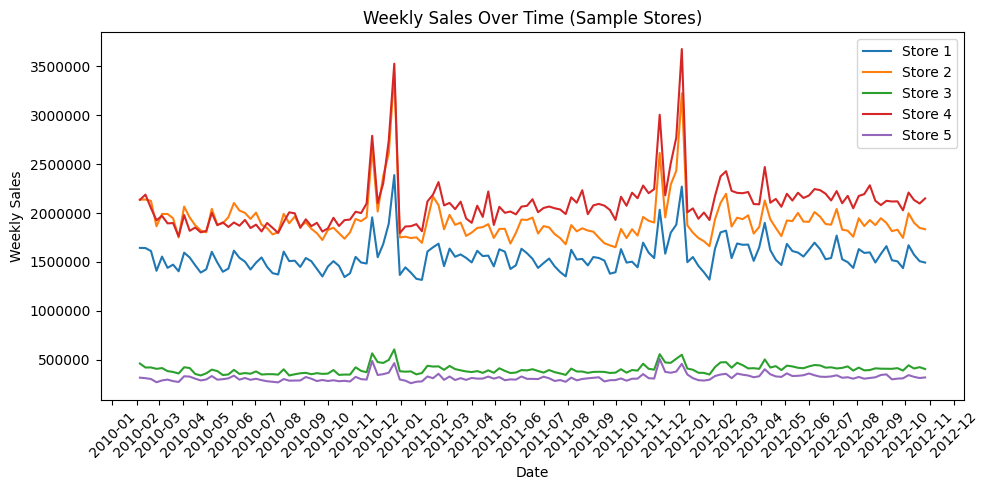

In [245]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stores_to_plot = df['Store'].cat.categories[:5]
plt.figure(figsize=(10,5))

for s in stores_to_plot:
    tmp = df[df['Store'] == s].sort_values('Date')
    plt.plot(tmp['Date'], tmp['Weekly_Sales'], label=f"Store {int(s)}")

plt.title("Weekly Sales Over Time (Sample Stores)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

# ✅ Monthly ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())                 # every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))       # format label

plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/4284847926.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_totals = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)


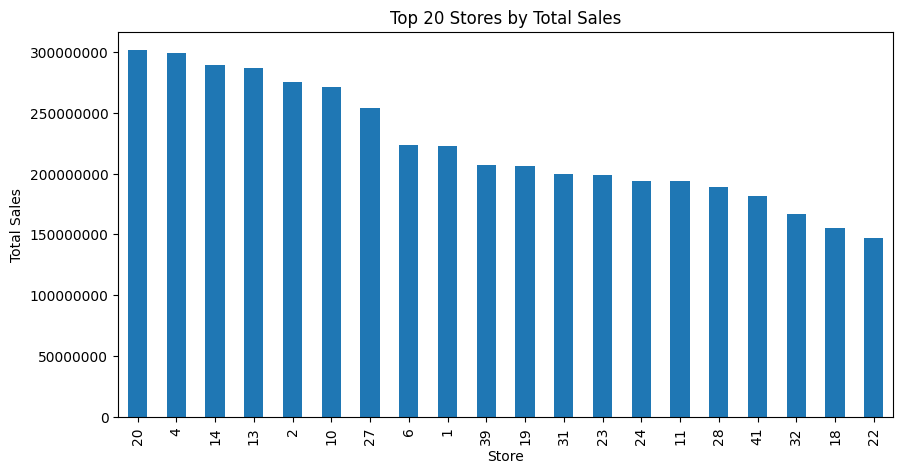

In [246]:
store_totals = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
store_totals.head(20).plot(kind='bar')
plt.title("Top 20 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.ticklabel_format(style='plain', axis='y') 
plt.show()


In [247]:
df['Date'].min(), df['Date'].max()


(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [248]:
df = df.sort_values('Date')
cut1 = df['Date'].quantile(0.70)
cut2 = df['Date'].quantile(0.85)

train = df[df['Date'] <= cut1].copy()
val   = df[(df['Date'] > cut1) & (df['Date'] <= cut2)].copy()
test  = df[df['Date'] > cut2].copy()


In [249]:
df = df.sort_values(['Store', 'Date'])
df['lag_1'] = df.groupby('Store', observed = True)['Weekly_Sales'].shift(1)


In [250]:
df['lag_1'].isna().sum()


np.int64(45)

In [251]:
df['Date'].min(), df['Date'].max(), df['Store'].nunique()


(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'), 45)

In [252]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,lag_1
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,1643690.90
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,1641957.44
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,1611968.17
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,1409727.59
...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,723086.20
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,713173.95
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,733455.07
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,734464.36


In [253]:
df = df.sort_values(['Store', 'Date'])

for lag in [1, 2, 4, 12, 52]:
    df[f'lag_{lag}'] = df.groupby('Store', observed = True)['Weekly_Sales'].shift(lag)


In [254]:
df['roll_mean_4']  = df.groupby('Store', observed = True)['Weekly_Sales'].shift(1).rolling(4).mean()
df['roll_mean_12'] = df.groupby('Store', observed = True)['Weekly_Sales'].shift(1).rolling(12).mean()


In [255]:
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
df['month']        = df['Date'].dt.month
df['year']         = df['Date'].dt.year


In [256]:
df['pre_holiday']  = df.groupby('Store', observed = True)['Holiday_Flag'].shift(-1)
df['post_holiday'] = df.groupby('Store', observed = True)['Holiday_Flag'].shift(1)


In [257]:
features = [
    'lag_1','lag_2','lag_4','lag_12','lag_52',
    'roll_mean_4','roll_mean_12',
    'Holiday_Flag','pre_holiday','post_holiday',
    'Temperature','Fuel_Price','CPI','Unemployment',
    'week_of_year','month','year','Store'
]

df_model = df.dropna(subset=features + ['Weekly_Sales'])

train = df_model[df_model['Date'] <= '2011-12-30']
val   = df_model[(df_model['Date'] > '2011-12-30') & (df_model['Date'] <= '2012-06-29')]
test  = df_model[df_model['Date'] > '2012-06-29']


In [258]:
X_train = pd.get_dummies(train[features], drop_first=True)
X_val   = pd.get_dummies(val[features], drop_first=True)
X_test  = pd.get_dummies(test[features], drop_first=True)

X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['Weekly_Sales']
y_val   = val['Weekly_Sales']
y_test  = test['Weekly_Sales']


In [259]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)
mae = mean_absolute_error(y_val, val_preds)
mae


54249.01804415351

In [260]:
val_baseline = val.dropna(subset=['lag_1'])
baseline_mae = mean_absolute_error(
    val_baseline['Weekly_Sales'], 
    val_baseline['lag_1']
)

baseline_mae


63568.32365811966

In [261]:
baseline_mae, mae


(63568.32365811966, 54249.01804415351)

In [262]:
test_preds = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae_pct = test_mae / y_test.mean() * 100
test_rmse_pct = test_rmse /  y_test.mean() * 100

print(f"MAE Percent Error: {test_mae_pct}")

print(f"RMSE Percent Error: {test_rmse_pct}")


MAE Percent Error: 4.800837463346844
RMSE Percent Error: 7.288786974552789


In [263]:
bmodel_mae = mean_absolute_error(y_test, test_preds)

print(bmodel_mae)

49596.87351161974


In [264]:
nmae_pct = bmodel_mae / y_test.mean() * 100
print(nmae_pct)

4.800837463346844


In [265]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
rmse


np.float64(80668.12408608988)

In [266]:
avg_sales = y_val.mean()
mae_pct = mae / avg_sales * 100
mae_pct


np.float64(5.242250088496007)

In [267]:
intercept = model.intercept_
print("Intercept:", intercept)

for feature, coef in coef_series.items():
    print(f"{feature}: {coef}")


Intercept: 6498.458594714524
lag_1: 0.0762011990395567
lag_2: 0.11865246839726806
lag_4: 0.08206797909830521
lag_12: -0.007559346351804499
lag_52: 0.7706908867975012
roll_mean_4: -0.15823410835730042
roll_mean_12: 0.12406600007567731
Holiday_Flag: 20821.488799536288
pre_holiday: -23953.43502922289
post_holiday: -7575.181680957297
Temperature: -93.25365109281996
Fuel_Price: -6950.559788994188
CPI: 321.0171698365006
Unemployment: -6183.948413637845
week_of_year: 6236.442305552627
month: -21406.29942289421
year: 0.0
Store_2: -83021.06086841002
Store_3: -16323.007172938189
Store_4: 115754.2568754539
Store_5: -21972.86866399045
Store_6: -54368.76228379577
Store_7: 31556.515080031844
Store_8: -18842.782476498647
Store_9: -5886.125925460777
Store_10: -28862.60474553223
Store_11: -16534.525083332803
Store_12: 54319.87179600216
Store_13: 35932.45456468805
Store_14: -109992.21388248113
Store_15: -22583.514429220395
Store_16: -14799.024876592819
Store_17: 25293.334042457125
Store_18: -72352.73218

In [268]:
coef_series.sort_values(key=abs, ascending=False).head(10)


Store_35   -161094.781556
Store_4     115754.256875
Store_14   -109992.213882
Store_2     -83021.060868
Store_36    -82030.836487
Store_18    -72352.732184
Store_38     70778.228401
Store_27    -64994.049784
Store_39     63104.429759
Store_6     -54368.762284
dtype: float64

In [269]:
df


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,lag_1,lag_2,lag_4,lag_12,lag_52,roll_mean_4,roll_mean_12,week_of_year,month,year,pre_holiday,post_holiday
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,2,2010,1.0,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,1643690.90,NaN,NaN,NaN,NaN,NaN,NaN,6,2,2010,0.0,0.0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,1641957.44,1643690.90,NaN,NaN,NaN,NaN,NaN,7,2,2010,0.0,1.0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,1611968.17,1641957.44,NaN,NaN,NaN,NaN,NaN,8,2,2010,0.0,0.0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,1409727.59,1611968.17,1643690.90,NaN,NaN,1.576836e+06,NaN,9,3,2010,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,723086.20,702238.27,734297.87,843361.10,698986.34,7.315338e+05,739007.869167,39,9,2012,0.0,0.0
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,713173.95,723086.20,766512.66,749817.08,753447.05,7.262528e+05,728158.940000,40,10,2012,0.0,0.0
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,733455.07,713173.95,702238.27,737613.65,720946.99,7.179884e+05,726795.439167,41,10,2012,0.0,0.0
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,734464.36,733455.07,723086.20,711671.58,771686.40,7.260449e+05,726532.998333,42,10,2012,0.0,0.0


In [270]:
file_path = '/kaggle/input/datasets/rutuspatel/walmart-dataset-retail/Walmart_Store_sales.csv'

yes = pd.read_csv(file_path)
yes

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [271]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


df['lag1_baseline'] = df['Weekly_Sales'].shift(1)


df_baseline = df.dropna(subset=['lag1_baseline'])

y_actual = df_baseline['Weekly_Sales']
baseline_prediction = df_baseline['lag1_baseline']

baseline_rmse = np.sqrt(mean_squared_error(y_actual, baseline_prediction))
baseline_mape = mean_absolute_percentage_error(y_actual, baseline_prediction) * 100


mean_sales = y_actual.mean()
mae_percent = (baseline_mae / mean_sales) * 100
rmse_percent = (baseline_rmse / mean_sales) * 100

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE %:", mae_percent, "%")
print("Baseline RMSE %:", rmse_percent, "%")

Baseline MAE: 63568.32365811966
Baseline RMSE: 186878.27441235117
Baseline MAE %: 6.072214717078121 %
Baseline RMSE %: 17.851107955776612 %


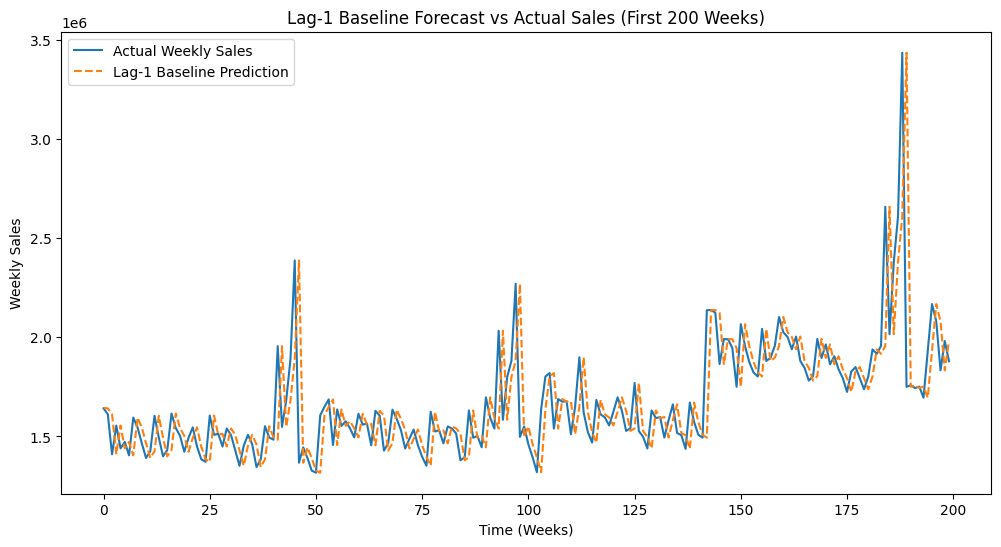

In [272]:
plt.figure(figsize=(12,6))

plt.plot(y_actual.values[:200], label="Actual Weekly Sales")
plt.plot(baseline_prediction.values[:200], label="Lag-1 Baseline Prediction", linestyle="--")

plt.title("Lag-1 Baseline Forecast vs Actual Sales (First 200 Weeks)")
plt.xlabel("Time (Weeks)")
plt.ylabel("Weekly Sales")
plt.legend()

plt.show()

In [273]:
import pandas as pd

coef_series = pd.Series(model.coef_, index=X_train.columns)
print(coef_series)

lag_1           0.076201
lag_2           0.118652
lag_4           0.082068
lag_12         -0.007559
lag_52          0.770691
                ...     
Store_41    50844.441194
Store_42    29467.338062
Store_43   -36064.092251
Store_44     7708.320903
Store_45    -7318.923285
Length: 61, dtype: float64


In [274]:
print(list(df.columns))
print(df.info())
print(df.describe())

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'lag_1', 'lag_2', 'lag_4', 'lag_12', 'lag_52', 'roll_mean_4', 'roll_mean_12', 'week_of_year', 'month', 'year', 'pre_holiday', 'post_holiday', 'lag1_baseline']
<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Store          6435 non-null   category      
 1   Date           6435 non-null   datetime64[ns]
 2   Weekly_Sales   6435 non-null   float64       
 3   Holiday_Flag   6435 non-null   int64         
 4   Temperature    6435 non-null   float64       
 5   Fuel_Price     6435 non-null   float64       
 6   CPI            6435 non-null   float64       
 7   Unemployment   6435 non-null   float64       
 8   lag_1          6390 non-null   float64       
 9   lag_2          6345 non-null   float64       
 10  lag_4          6255 

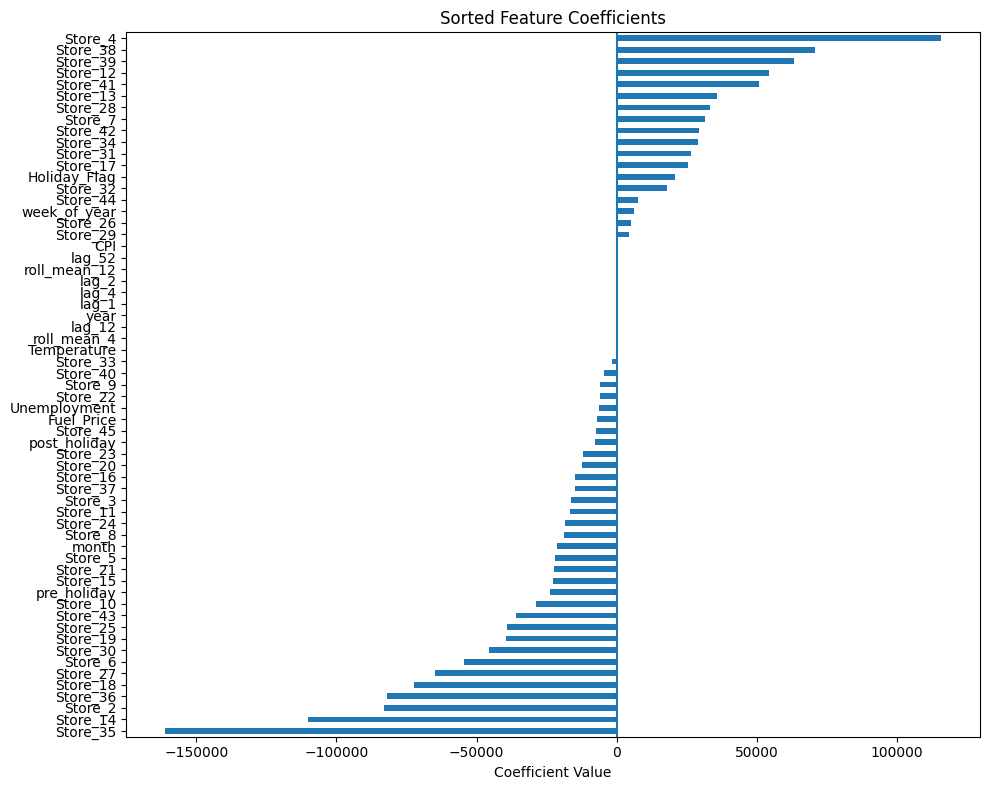

In [275]:
import matplotlib.pyplot as plt
import pandas as pd

coef_df = coef_series.sort_values()

plt.figure(figsize=(10, 8))
coef_df.plot(kind='barh')
plt.title("Sorted Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(0)
plt.tight_layout()
plt.show()

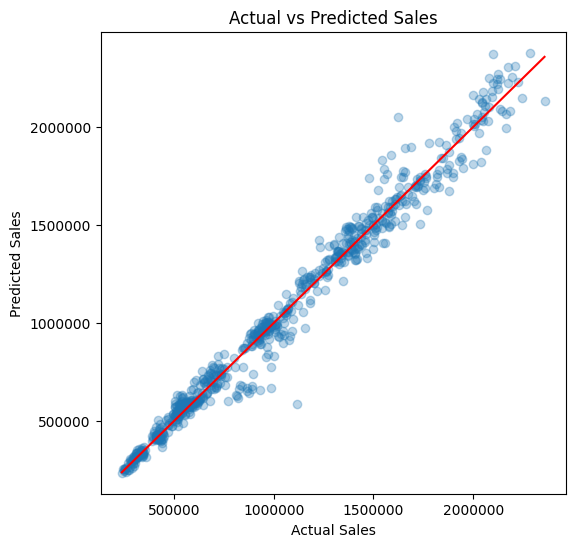

In [276]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, test_preds, alpha=0.3)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.ticklabel_format(style='plain', axis='both')  

plt.show()


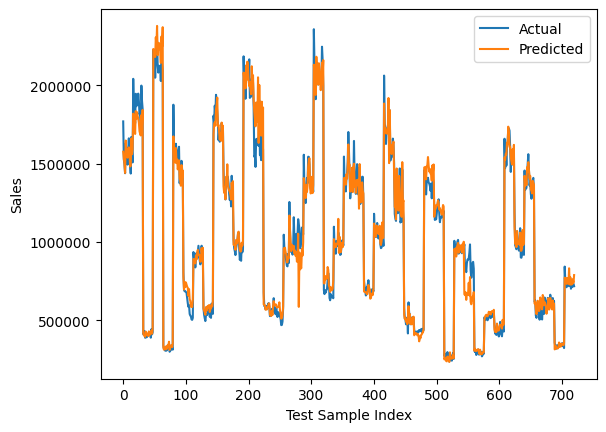

In [277]:
plt.plot(y_test.values, label="Actual")
plt.plot(test_preds, label="Predicted")

plt.xlabel("Test Sample Index")
plt.ylabel("Sales")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.show()


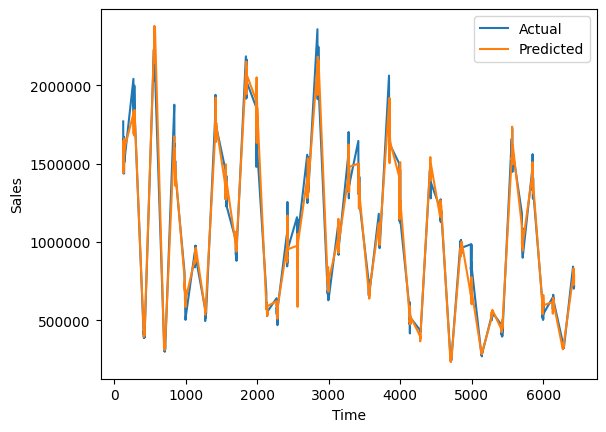

In [278]:
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, test_preds, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Sales")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.show()

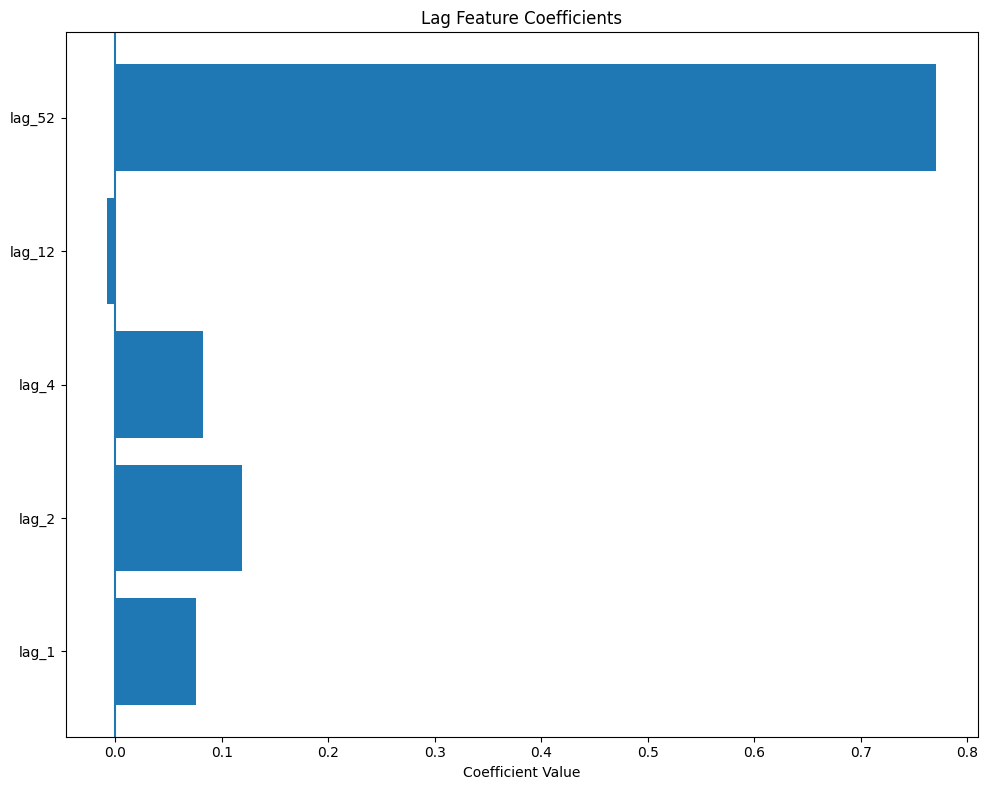

In [279]:
import matplotlib.pyplot as plt

# Convert to dictionary if not already
coef_dict = coef_series.to_dict()

# FILTER: keep only lag variables
lag_coef_dict = {k: v for k, v in coef_dict.items() if "lag_" in k.lower()}

features = list(lag_coef_dict.keys())
values = list(lag_coef_dict.values())

plt.figure(figsize=(10, 8))
plt.barh(features, values)
plt.xlabel("Coefficient Value")
plt.title("Lag Feature Coefficients")
plt.axvline(0)
plt.tight_layout()
plt.show()

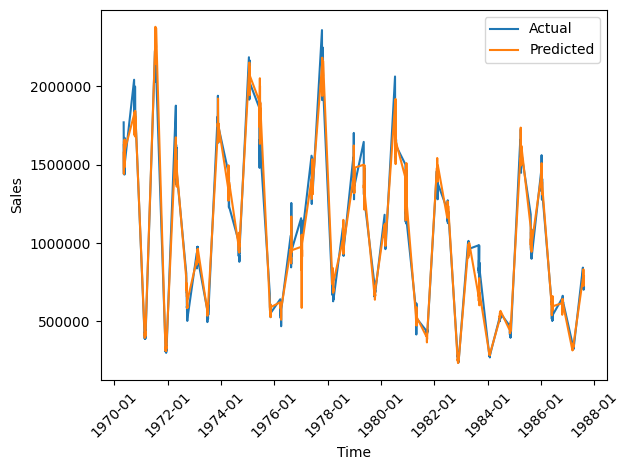

In [280]:
import matplotlib.dates as mdates

plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, test_preds, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Sales")

# Format dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.tight_layout()
plt.show()

In [281]:
print(type(y_test.index))


<class 'pandas.core.indexes.base.Index'>


In [282]:

df['Date'] = pd.to_datetime(df['Date'])


X = df.set_index('Date')

In [283]:
selected_stores = df['Store'].unique()[:5]  

In [284]:
filtered_idx = df.loc[y_test.index]['Store'].isin(selected_stores)

y_test_filtered = y_test[filtered_idx]
test_preds_filtered = test_preds[filtered_idx]
test_dates_filtered = df.loc[y_test_filtered.index, 'Date']
store_filtered = df.loc[y_test_filtered.index, 'Store']

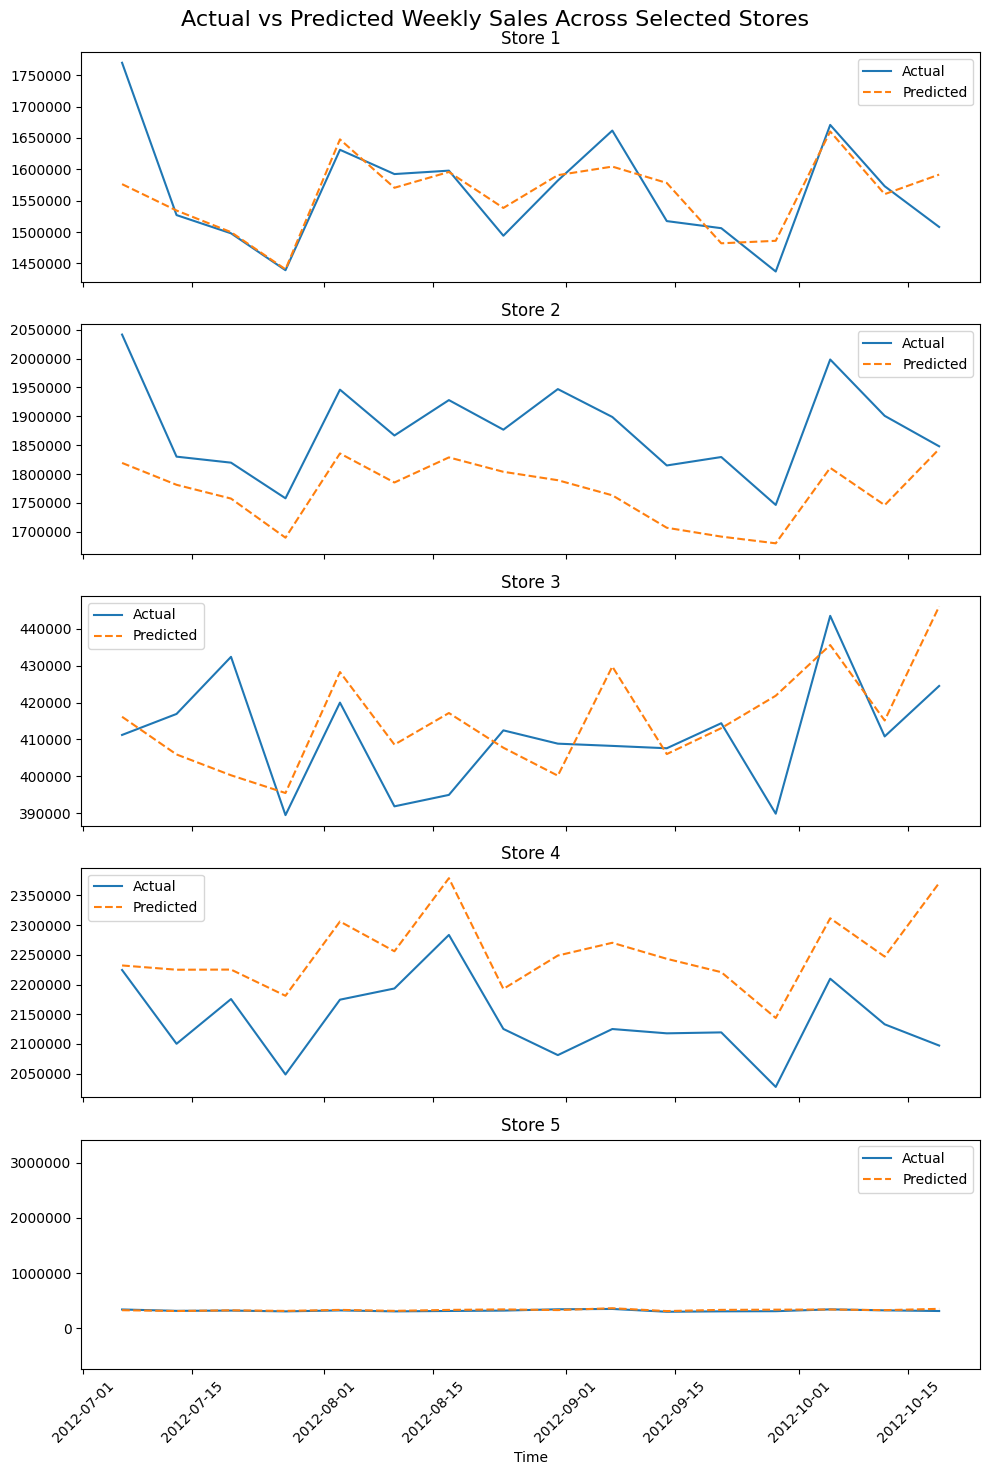

In [285]:
fig, axes = plt.subplots(5, 1, figsize=(10,15), sharex=True)

for i, store in enumerate(selected_stores):
    store_mask = store_filtered == store
    
    axes[i].plot(
        test_dates_filtered[store_mask],
        y_test_filtered[store_mask],
        label="Actual"
    )
    
    axes[i].plot(
        test_dates_filtered[store_mask],
        test_preds_filtered[store_mask],
        linestyle='--',
        label="Predicted"
    )
    
    axes[i].set_title(f"Store {store}")
    axes[i].ticklabel_format(style='plain', axis='y')
    axes[i].legend()
padding = (y_max - y_min) * .5
plt.ylim(y_min - padding, y_max + padding)
plt.suptitle("Actual vs Predicted Weekly Sales Across Selected Stores", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

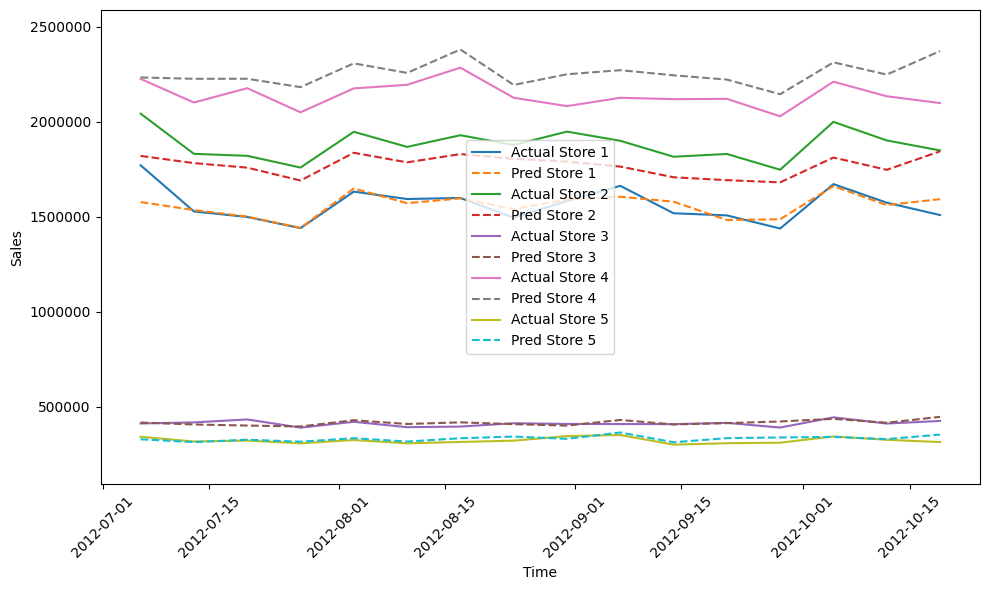

In [286]:
plt.figure(figsize=(10,6))

for store in selected_stores:
    store_mask = store_filtered == store
    
    plt.plot(
        test_dates_filtered[store_mask],
        y_test_filtered[store_mask],
        label=f"Actual Store {store}"
    )
    
    plt.plot(
        test_dates_filtered[store_mask],
        test_preds_filtered[store_mask],
        linestyle='--',
        label=f"Pred Store {store}"
    )

plt.xlabel("Time")
plt.ylabel("Sales")


y_min = min(y_test_filtered.min(), test_preds_filtered.min())
y_max = max(y_test_filtered.max(), test_preds_filtered.max())
padding = (y_max - y_min) * 0.1
plt.ylim(y_min - padding, y_max + padding)

plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

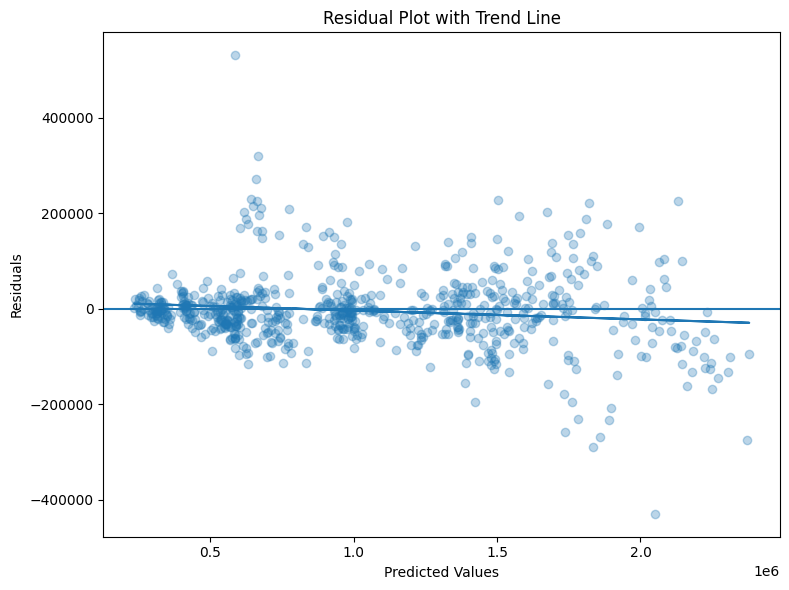

In [287]:
import numpy as np

plt.figure(figsize=(8,6))
plt.scatter(test_preds, residuals, alpha=0.3)

z = np.polyfit(test_preds, residuals, 1)
p = np.poly1d(z)
plt.plot(test_preds, p(test_preds))

plt.axhline(0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot with Trend Line")

plt.tight_layout()
plt.show()

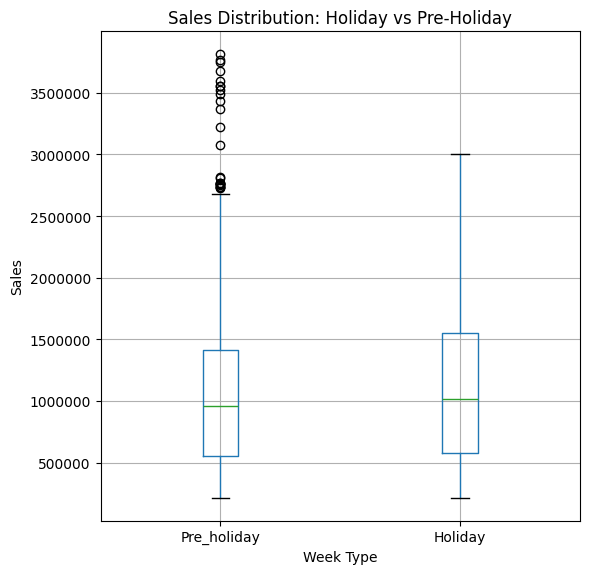

In [288]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(6,6))

ax = plt.gca()

df.boxplot(column="Weekly_Sales", by="Holiday_Flag", ax=ax)


ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.xticks([1, 2], ["Pre_holiday", "Holiday"])
plt.xlabel("Week Type")
plt.ylabel("Sales")
plt.title("Sales Distribution: Holiday vs Pre-Holiday")
plt.suptitle("")

plt.tight_layout()
plt.show()